**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Dr. Irvin Hussein López Nava

## ICD - 10: Regresión lineal

Sesión 10 del curso. Diapositivas: [icd-10-regresion.pdf](https://github.com/husseinlopez/icd2026/blob/main/clases/icd-10-regresion.pdf)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/husseinlopez/icd2026/blob/main/icd-10-regresion.ipynb)

En clase vimos la regresión lineal como el primer modelo supervisado del curso: una recta, o un hiperplano si hay varias variables, que predice un valor numérico a partir de otros. Sus parámetros se eligen para que el error cuadrático medio sea mínimo, y hay dos maneras de encontrarlos: iterar con descenso de gradiente o resolver de una vez con mínimos cuadrados. También vimos cómo saber si el modelo sirve: evaluarlo con datos que no vio y revisar sus residuales.

Este notebook lleva esas ideas al código con un solo conjunto de datos clínicos. Primero programamos a mano la regresión simple, con las fórmulas de las diapositivas, y comprobamos que el descenso de gradiente, la solución cerrada y scikit-learn llegan a la misma recta; en el camino aparece un problema práctico que las fórmulas no muestran. Después pasamos a la regresión múltiple: la evaluamos como modelo para predecir, revisamos sus supuestos y la usamos para explicar una asociación, como se hace en los estudios clínicos.

La última sección cambia la pregunta: ¿qué pasa si en lugar de un número queremos predecir una clase? Es el tema de la próxima sesión y el de la Tarea 2.

---

### Preparación

Además de NumPy, pandas y Matplotlib, esta sesión estrena dos bibliotecas: **scikit-learn**, la de aprendizaje automático que usaremos el resto del curso, y **statsmodels**, que en la sección 5 reporta los intervalos de confianza que scikit-learn omite. Las dos vienen instaladas en Colab; en tu máquina se instalan con `pip install scikit-learn statsmodels`. Sus funciones se importan en el momento en que se usan por primera vez, para que se vea qué pieza resuelve cada paso.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import statsmodels

print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", __import__("matplotlib").__version__)
print("scikit-learn", sklearn.__version__)
print("statsmodels ", statsmodels.__version__)

numpy        2.4.4
pandas       3.0.2
matplotlib   3.10.9
scikit-learn 1.8.0
statsmodels  0.15.0


Paleta y estilo, definidos una sola vez como en las sesiones anteriores. Los colores son los de las diapositivas. El naranja se reserva para lo que produce el modelo, sea una recta o una predicción, igual que en las figuras de la clase.

In [2]:
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
NARANJA = "#E76A28"     # lo que produce el modelo
GRIS = "#5B6584"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlecolor": AZUL_OSCURO,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelcolor": AZUL_OSCURO,
    "axes.edgecolor": "#C9CFDF",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E3E6EF",
    "xtick.color": GRIS,
    "ytick.color": GRIS,
    "legend.frameon": False,
})

SEMILLA = 42    # fija las particiones y los sorteos para que los resultados se repitan

---

### Los datos

**Progresión de la diabetes a un año** (Efron *et al.*, 2004).

A 442 pacientes con diabetes se les midieron diez variables al inicio del estudio —edad, sexo, índice de masa corporal, presión arterial media y seis mediciones en suero sanguíneo— y, un año después, qué tanto había avanzado la enfermedad. Es el ejemplo clínico que mencionamos en el slide 15.

- **Quién lo recolectó.** Se publicó con el artículo de Efron, Hastie, Johnstone y Tibshirani (2004) sobre *least angle regression*. scikit-learn lo incluye como `load_diabetes`.
- **Unidad de observación.** Un paciente. Cada fila es una persona distinta, así que el supuesto de independencia del slide 18 es razonable.
- **Variable objetivo.** El artículo la describe solo como «una medida cuantitativa de la progresión de la enfermedad un año después». Va de 25 a 346, mayor es peor, y no tiene unidades declaradas.
- **Licencia.** Viene dentro de scikit-learn, que se distribuye con licencia BSD. Los datos originales no declaran una licencia; para el uso académico basta con citar el artículo.

A diferencia de las sesiones anteriores, no hay archivo que cargar: el conjunto viene con scikit-learn y funciona igual en Colab y en tu máquina, sin conexión.

Un detalle importa. Por omisión, `load_diabetes` entrega las diez variables ya centradas y escaladas, con valores como 0.0381 para la edad. Pedimos las unidades originales con `scaled=False`, para que el IMC esté en kg/m² y la presión en mmHg. La sección 1 muestra por qué esa diferencia no es cosmética.

In [3]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True, scaled=False)
X = diabetes.data        # las diez variables independientes
y = diabetes.target      # la progresión a un año

print(f"{X.shape[0]} pacientes × {X.shape[1]} variables")
X.head()

442 pacientes × 10 variables


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


Los nombres de columna se conservan como vienen de la fuente. La documentación no da las unidades de `s1` a `s6`; por sus rangos, las de colesterol y glucosa parecen estar en mg/dL. Tampoco dice qué código de `sex` corresponde a cada sexo.

| Columna | Qué mide | Rango |
|---|---|---|
| `age` | Edad (años) | 19 a 79 |
| `sex` | Sexo, codificado como 1 y 2 | 1, 2 |
| `bmi` | Índice de masa corporal, IMC (kg/m²) | 18.0 a 42.2 |
| `bp` | Presión arterial media (mmHg) | 62 a 133 |
| `s1` | Colesterol total | 97 a 301 |
| `s2` | Colesterol LDL | 41.6 a 242.4 |
| `s3` | Colesterol HDL | 22 a 99 |
| `s4` | Colesterol total entre HDL | 2 a 9.09 |
| `s5` | Logaritmo de los triglicéridos, según la documentación | 3.26 a 6.11 |
| `s6` | Glucosa | 58 a 124 |
| `target` | Progresión de la enfermedad a un año | 25 a 346 |

Los rangos de la tabla salen de la celda siguiente, que además confirma que no hay faltantes.

In [4]:
tabla = pd.concat([X, y], axis=1)
resumen = tabla.agg(["min", "max"]).T
resumen["faltantes"] = tabla.isna().sum()
resumen.round(2)

,min,max,faltantes
age,19.00,79.00,0
sex,1.00,2.00,0
bmi,18.00,42.20,0
bp,62.00,133.00,0
s1,97.00,301.00,0
s2,41.60,242.40,0
s3,22.00,99.00,0
s4,2.00,9.09,0
s5,3.26,6.11,0
s6,58.00,124.00,0


---

## 1. Regresión lineal simple

Empezamos con una sola variable independiente. ¿Cuál? La que más se asocia con la progresión. La correlación de Pearson mide justamente qué tan bien describe una recta la relación entre dos variables.

In [5]:
X.corrwith(y).sort_values(ascending=False).round(2)

bmi    0.59
s5     0.57
bp     0.44
s4     0.43
s6     0.38
s1     0.21
age    0.19
s2     0.17
sex    0.04
s3    -0.39
dtype: float64

**Lectura.** El IMC es la variable con la asociación lineal más fuerte (0.59), seguida del logaritmo de los triglicéridos (0.57) y la presión arterial (0.44). El colesterol HDL es la única con signo negativo (−0.39): más HDL, menos progresión. Usamos el IMC como *x* y la progresión como *y*.

### Mínimos cuadrados

El slide 29 da la solución cerrada para el caso simple:

$$\theta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} \qquad\qquad \theta_0 = \bar{y} - \theta_1\,\bar{x}$$

Se traduce a NumPy casi símbolo por símbolo. Trabajamos con arreglos de NumPy en lugar de columnas de pandas porque más adelante haremos miles de iteraciones con ellos.

In [6]:
x = X["bmi"].to_numpy()        # IMC: la variable independiente
y_obs = y.to_numpy()           # progresión observada: la variable dependiente

theta1 = np.sum((x - x.mean()) * (y_obs - y_obs.mean())) / np.sum((x - x.mean()) ** 2)
theta0 = y_obs.mean() - theta1 * x.mean()

print(f"θ0 = {theta0:.2f}")
print(f"θ1 = {theta1:.3f}")

θ0 = -117.77
θ1 = 10.233


**Lectura.** La pendiente dice que cada kg/m² adicional de IMC se asocia con 10.2 unidades más de progresión. El intercepto, −117.8, es la predicción para un IMC de cero: un valor que no existe y que queda muy lejos de los datos, que van de 18 a 42. El intercepto ancla la recta, pero solo se interpreta cuando *x* = 0 tiene sentido.

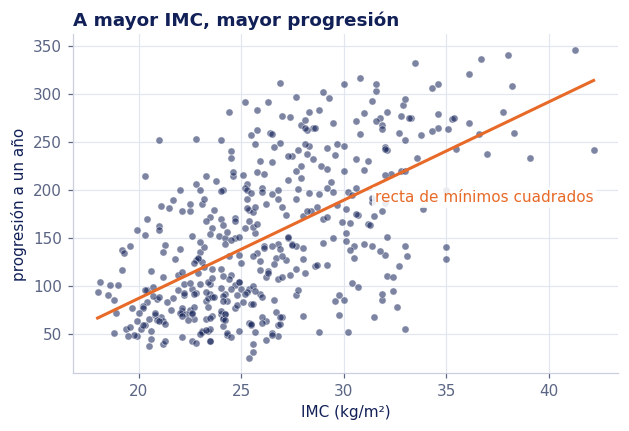

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 4))

ax.scatter(x, y_obs, s=22, color=AZUL_OSCURO, alpha=0.55, edgecolor="white", linewidth=0.5)
malla = np.linspace(x.min(), x.max(), 100)
ax.plot(malla, theta0 + theta1 * malla, color=NARANJA, linewidth=2)
ax.text(malla[-1], 200, "recta de mínimos cuadrados", color=NARANJA, ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85))

ax.set_xlabel("IMC (kg/m²)")
ax.set_ylabel("progresión a un año")
ax.set_title("A mayor IMC, mayor progresión")
plt.show()

**Lectura.** La recta capta la tendencia, pero la nube es ancha: para un mismo IMC hay pacientes con progresiones muy distintas. Con una sola variable no se puede pedir más; la sección 2 agrega las otras nueve.

### Descenso de gradiente

Ahora el mismo problema por la vía iterativa de los slides 23 a 26. Partimos de θ0 = θ1 = 0 y en cada paso movemos los parámetros en contra del gradiente del costo:

$$\theta_0 \leftarrow \theta_0 - \alpha\,\frac{2}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i) \qquad\qquad \theta_1 \leftarrow \theta_1 - \alpha\,\frac{2}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)\,x_i$$

La función guarda los parámetros y el costo *J* de cada paso, para poder graficar después el recorrido.

In [8]:
def descenso_gradiente(x, y, alfa, iteraciones):
    # Regresión lineal simple por descenso de gradiente (slides 24 a 26).
    n = len(x)
    theta0, theta1 = 0.0, 0.0
    historia = []
    for _ in range(iteraciones):
        error = (theta0 + theta1 * x) - y            # ŷ − y
        historia.append((theta0, theta1, np.mean(error ** 2)))
        d_theta0 = 2 / n * np.sum(error)             # ∂J/∂θ0
        d_theta1 = 2 / n * np.sum(error * x)         # ∂J/∂θ1
        theta0 = theta0 - alfa * d_theta0            # las dos derivadas se calcularon
        theta1 = theta1 - alfa * d_theta1            # con los θ del paso anterior
    historia = pd.DataFrame(historia, columns=["theta0", "theta1", "costo"])
    return theta0, theta1, historia

In [9]:
gd_theta0, gd_theta1, historia = descenso_gradiente(x, y_obs, alfa=0.001, iteraciones=1000)

costo_minimo = np.mean((theta0 + theta1 * x - y_obs) ** 2)
print(f"J al inicio:       {historia['costo'].iloc[0]:>8.0f}")
print(f"J tras 1000 pasos: {historia['costo'].iloc[-1]:>8.0f}")
print(f"J en el mínimo:    {costo_minimo:>8.0f}")

pd.DataFrame({
    "mínimos cuadrados": [theta0, theta1],
    "descenso de gradiente": [gd_theta0, gd_theta1],
}, index=["θ0", "θ1"]).round(2)

J al inicio:          29074
J tras 1000 pasos:     4231
J en el mínimo:        3890


,mínimos cuadrados,descenso de gradiente
θ0,-117.77,-6.03
θ1,10.23,6.11


**Lectura.** No llegó. Después de mil pasos el intercepto va en −6 cuando debería estar en −118, y la pendiente, 6.1 en lugar de 10.2, lo compensa a medias. El costo sí bajó mucho, de 29 074 a 4 231, pero el mínimo es 3 890: el algoritmo avanza por una zona donde *J* casi no cambia.

### ¿Por qué no llega?

La causa está en la escala de *x*. La derivada respecto a θ1 multiplica cada error por $x_i$, que aquí vale alrededor de 26, así que resulta del orden de 26 veces la derivada respecto a θ0. La tasa de aprendizaje tiene que ser lo bastante chica para que θ1 no se dispare, y con esa misma α, θ0 apenas se mueve.

¿Y si subimos α? Probamos tres valores.

In [10]:
for alfa in [0.001, 0.0013, 0.0014]:
    t0, t1, h = descenso_gradiente(x, y_obs, alfa, iteraciones=1000)
    print(f"α = {alfa:<6}  θ0 = {t0:>8.2f}   θ1 = {t1:>9.2f}   J = {h['costo'].iloc[-1]:.4g}")

α = 0.001   θ0 =    -6.03   θ1 =      6.11   J = 4231
α = 0.0013  θ0 =    -7.84   θ1 =      6.18   J = 4220
α = 0.0014  θ0 =   -45.95   θ1 =  -1011.02   J = 7.344e+08


**Lectura.** Con 0.0013 mejora apenas; con 0.0014 diverge: θ1 rebota de un lado a otro con amplitud creciente y el costo explota. No hay una α que sirva a la vez para los dos parámetros. Sin tocar los datos, la única salida es dar más pasos.

In [11]:
t0, t1, _ = descenso_gradiente(x, y_obs, alfa=0.001, iteraciones=100_000)
print(f"Con 100 000 pasos: θ0 = {t0:.2f}   θ1 = {t1:.3f}")

Con 100 000 pasos: θ0 = -117.26   θ1 = 10.214


Cien mil pasos para una recta con un solo predictor. Es el problema que anunciaba el slide 26.

### Estandarizar x

La alternativa es cambiar la escala de *x* en lugar de dar más pasos. Estandarizar es restarle su media y dividir entre su desviación estándar:

$$z_i = \frac{x_i - \bar{x}}{s_x}$$

*z* mide el IMC en desviaciones estándar respecto al promedio: 0 es el IMC promedio y 1 es uno 4.4 kg/m² más alto. Las dos derivadas quedan en la misma escala y se puede usar una α mucho mayor.

Como el modelo se ajusta en otras unidades, al final hay que traducir los parámetros. Si $\hat{y} = a + b\,z$, sustituir $z = (x - \bar{x})/s_x$ da

$$\theta_1 = \frac{b}{s_x} \qquad\qquad \theta_0 = a - \theta_1\,\bar{x}$$

In [12]:
media_x, desv_x = x.mean(), x.std()
z = (x - media_x) / desv_x

a, b, historia_z = descenso_gradiente(z, y_obs, alfa=0.1, iteraciones=50)

theta1_z = b / desv_x              # de vuelta a kg/m²
theta0_z = a - theta1_z * media_x

pd.DataFrame({
    "mínimos cuadrados": [theta0, theta1],
    "descenso, IMC en kg/m² (1000 pasos)": [gd_theta0, gd_theta1],
    "descenso, IMC estandarizado (50 pasos)": [theta0_z, theta1_z],
}, index=["θ0", "θ1"]).round(3)

,mínimos cuadrados,"descenso, IMC en kg/m² (1000 pasos)","descenso, IMC estandarizado (50 pasos)"
θ0,-117.773,-6.029,-117.772
θ1,10.233,6.112,10.233


Cincuenta pasos, y llega al mismo θ que la fórmula. La figura muestra por qué. Cada curva une los puntos con el mismo costo *J*, y la línea naranja es el recorrido del descenso desde θ = (0, 0).

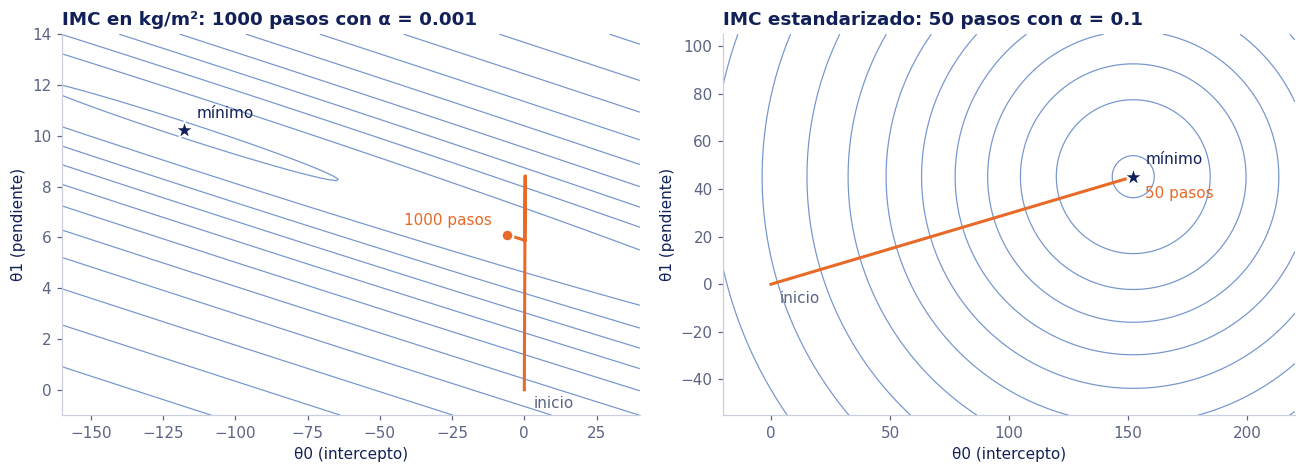

In [13]:
def costo_en_malla(x, y, t0, t1):
    # J(θ0, θ1) en cada punto de la malla. Como el MSE es cuadrático en θ,
    # basta con unas cuantas sumas de los datos.
    return (t0 ** 2 + 2 * t0 * t1 * x.mean() + t1 ** 2 * np.mean(x ** 2)
            - 2 * t0 * y.mean() - 2 * t1 * np.mean(x * y) + np.mean(y ** 2))


fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
paneles = [
    (axes[0], x, historia, (theta0, theta1), (-160, 40), (-1, 14),
     "IMC en kg/m²: 1000 pasos con α = 0.001", "1000 pasos", (-10, 6), "right"),
    (axes[1], z, historia_z, (y_obs.mean(), theta1 * desv_x), (-20, 220), (-55, 105),
     "IMC estandarizado: 50 pasos con α = 0.1", "50 pasos", (8, -14), "left"),
]
for ax, xs, h, minimo, rango0, rango1, titulo, etiqueta, desplazamiento, alineacion in paneles:
    t0, t1 = np.meshgrid(np.linspace(*rango0, 300), np.linspace(*rango1, 300))
    costo = costo_en_malla(xs, y_obs, t0, t1)
    niveles = np.geomspace(costo.min() * 1.02, costo.max(), 12)
    ax.contour(t0, t1, costo, levels=niveles, colors=AZUL, linewidths=0.8)
    ax.plot(h["theta0"], h["theta1"], color=NARANJA, linewidth=2)
    ax.scatter(h["theta0"].iloc[-1], h["theta1"].iloc[-1], s=60, color=NARANJA,
               edgecolor="white", linewidth=1.5, zorder=3)
    ax.scatter(*minimo, s=160, marker="*", color=AZUL_OSCURO, edgecolor="white",
               linewidth=1, zorder=4)
    ax.annotate("mínimo", minimo, xytext=(8, 8), textcoords="offset points", color=AZUL_OSCURO)
    ax.annotate(etiqueta, (h["theta0"].iloc[-1], h["theta1"].iloc[-1]), xytext=desplazamiento,
                textcoords="offset points", color=NARANJA, ha=alineacion)
    ax.annotate("inicio", (0, 0), xytext=(6, -12), textcoords="offset points", color=GRIS)
    ax.set_title(titulo)
    ax.set_xlabel("θ0 (intercepto)")
    ax.set_ylabel("θ1 (pendiente)")
    ax.grid(False)
axes[1].set_aspect("equal")    # misma escala en los dos ejes: los círculos se ven como círculos

fig.tight_layout()
plt.show()

**Lectura.** Con el IMC en kg/m² (izquierda), el costo forma un valle largo y estrecho. Los primeros pasos rebotan de una pared a otra del valle, casi en vertical; después el algoritmo avanza a lo largo del valle con pasos diminutos, y tras mil pasos sigue lejos del mínimo. Con el IMC estandarizado (derecha), las curvas son círculos, el gradiente apunta directo al mínimo y bastan unos cuantos pasos. A la derecha los ejes son los parámetros de *z*: el intercepto es la progresión promedio, 152, y la pendiente es el cambio por desviación estándar de IMC.

En la regresión múltiple el problema crece, porque cada variable tiene su propia escala: edad en años, colesterol en cientos, triglicéridos en logaritmo. Por eso, antes de cualquier método que use gradientes, se estandariza.

### Con scikit-learn

`LinearRegression` resuelve los mínimos cuadrados directamente, sin α ni iteraciones. Dos detalles de su interfaz, que se repiten en todo scikit-learn: `X` siempre es una tabla de dos dimensiones, aunque tenga una sola columna (de ahí los corchetes dobles en `X[["bmi"]]`), y lo aprendido se guarda en atributos que terminan en guion bajo, como `coef_`.

In [14]:
from sklearn.linear_model import LinearRegression

modelo_simple = LinearRegression().fit(X[["bmi"]], y)

pd.DataFrame({
    "fórmula de mínimos cuadrados": [theta0, theta1],
    "descenso de gradiente (z)": [theta0_z, theta1_z],
    "scikit-learn": [modelo_simple.intercept_, modelo_simple.coef_[0]],
}, index=["θ0", "θ1"]).round(4)

,fórmula de mínimos cuadrados,descenso de gradiente (z),scikit-learn
θ0,-117.7734,-117.7717,-117.7734
θ1,10.2331,10.2330,10.2331


**Lectura.** Tres caminos, la misma recta, como adelantaba el slide 29. La diferencia es práctica: la fórmula y scikit-learn la obtienen de una vez, mientras que el descenso de gradiente pide elegir α y un número de pasos y, de preferencia, estandarizar. ¿Para qué sirve entonces? Para los modelos que no tienen solución cerrada. El primero que veremos es la regresión logística, en la próxima sesión.

---

## 2. Regresión lineal múltiple

Con *p* variables, el modelo del slide 30 es

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_p x_p$$

En scikit-learn no cambia nada: el mismo `LinearRegression`, ahora con las diez columnas.

En esta sección ajustamos con los 442 pacientes porque solo queremos leer los coeficientes. Para medir qué tan bien predice el modelo, en la sección 3 apartamos datos de prueba.

In [15]:
modelo_multiple = LinearRegression().fit(X, y)

coeficientes = pd.Series(modelo_multiple.coef_, index=X.columns, name="θj")
print(f"θ0 = {modelo_multiple.intercept_:.2f}")
coeficientes.round(3).to_frame()

θ0 = -334.57


,θj
age,-0.036
sex,-22.860
bmi,5.603
bp,1.117
s1,-1.090
s2,0.746
s3,0.372
s4,6.534
s5,68.483
s6,0.280


### Cómo se lee un coeficiente

El coeficiente de `bmi` es 5.6: **manteniendo las otras nueve variables constantes**, un kg/m² más de IMC sube la predicción 5.6 unidades. En la regresión simple era 10.2. No hay contradicción. Cuando era la única variable, el IMC cargaba también con lo que comparte con otras —las personas con IMC alto suelen tener también la presión y los triglicéridos más altos, con correlaciones de 0.40 y 0.45—, y en el modelo múltiple esa parte se reparte entre ellas. En la jerga de los estudios clínicos, 10.2 es la asociación *cruda* y 5.6 la asociación *ajustada* por las demás variables: es el primer uso del slide 35.

### Un coeficiente grande no es una variable importante

El coeficiente más grande es el de `s5`, 68.5, contra 5.6 del IMC. ¿Es `s5` doce veces más importante? No necesariamente: `s5` es un logaritmo que solo varía entre 3.3 y 6.1, así que «una unidad más» es un cambio enorme. Cada θj está en las unidades de su variable (slide 30).

Para comparar hay que usar una escala común. Multiplicar θj por la desviación estándar de su variable da el cambio en la predicción cuando la variable sube una desviación estándar. Es lo mismo que ajustar el modelo con las variables estandarizadas.

In [16]:
desviaciones = X.std()

comparacion = pd.DataFrame({
    "θj (por unidad)": coeficientes,
    "desviación estándar": desviaciones,
    "θj × desviación": coeficientes * desviaciones,
})
comparacion.sort_values("θj × desviación", key=abs, ascending=False).round(2)

,θj (por unidad),desviación estándar,θj × desviación
s1,-1.09,34.61,-37.72
s5,68.48,0.52,35.77
bmi,5.60,4.42,24.75
s2,0.75,30.41,22.70
bp,1.12,13.83,15.45
sex,-22.86,0.50,-11.42
s4,6.53,1.29,8.43
s3,0.37,12.93,4.81
s6,0.28,11.50,3.22
age,-0.04,13.11,-0.48


**Lectura.** En la misma escala, `s5` sigue arriba (36) pero el IMC ya no está doce veces abajo (25). Y aparecen dos sorpresas: `s1` tiene el efecto más grande en valor absoluto (−38) y `s2` el cuarto (23), con signos opuestos. El colesterol total resta y el LDL suma, aunque cada uno por separado se asocia positivamente con la progresión (0.21 y 0.17 en la primera tabla). Eso merece una revisión.

### Colinealidad: s1 y s2

El colesterol LDL es una parte del colesterol total, así que `s1` y `s2` miden casi lo mismo. Es el supuesto de no colinealidad del slide 18. Veamos qué les pasa a los coeficientes si quitamos una de las dos.

In [17]:
print(f"Correlación entre s1 y s2: {X['s1'].corr(X['s2']):.2f}")

filas = {}
for nombre, quitar in [("las 10 variables", []), ("sin s2", ["s2"]), ("sin s1", ["s1"])]:
    X_i = X.drop(columns=quitar)
    modelo_i = LinearRegression().fit(X_i, y)
    c = pd.Series(modelo_i.coef_, index=X_i.columns)
    filas[nombre] = {"θ bmi": c["bmi"], "θ s1": c.get("s1", np.nan),
                     "θ s2": c.get("s2", np.nan), "R²": modelo_i.score(X_i, y)}

pd.DataFrame(filas).T.round(3)

Correlación entre s1 y s2: 0.90


,θ bmi,θ s1,θ s2,R²
las 10 variables,5.603,-1.090,0.746,0.518
sin s2,5.698,-0.314,NaN,0.516
sin s1,5.697,NaN,-0.224,0.514


**Lectura.** Quitar `s2` lleva el coeficiente de `s1` de −1.09 a −0.31. Quitar `s1` hace algo peor con el de `s2`: pasa de +0.75 a −0.22, cambia de signo. Mientras tanto el R² casi no se mueve, y el IMC tampoco. Como `s1` y `s2` cuentan casi la misma historia, el modelo puede repartir su efecto de muchas maneras que predicen igual de bien, y ninguna de ellas es «la» interpretación. Con colinealidad, las predicciones siguen siendo útiles; los coeficientes individuales, no.

### Las ecuaciones normales

El slide 30 da la solución de mínimos cuadrados en forma matricial, $\hat{\theta} = (X^T X)^{-1} X^T y$, con una columna de unos en *X* para el intercepto. En código conviene no invertir la matriz sino resolver el sistema $(X^T X)\,\theta = X^T y$, que da lo mismo con menos error numérico.

In [18]:
A = np.column_stack([np.ones(len(X)), X.to_numpy()])     # columna de unos para θ0
theta_normal = np.linalg.solve(A.T @ A, A.T @ y.to_numpy())

pd.DataFrame({
    "ecuaciones normales": theta_normal,
    "scikit-learn": np.r_[modelo_multiple.intercept_, modelo_multiple.coef_],
}, index=["θ0"] + list(X.columns)).round(4)

,ecuaciones normales,scikit-learn
θ0,-334.5671,-334.5671
age,-0.0364,-0.0364
sex,-22.8596,-22.8596
bmi,5.6030,5.6030
bp,1.1168,1.1168
s1,-1.0900,-1.0900
s2,0.7465,0.7465
s3,0.3720,0.3720
s4,6.5338,6.5338
s5,68.4831,68.4831


**Lectura.** Coinciden. scikit-learn no forma $X^T X$: resuelve los mínimos cuadrados con una descomposición de *X* que es más estable cuando hay columnas muy correlacionadas, como `s1` y `s2`. Con estos datos la diferencia no se nota; con colinealidad más severa, sí.

---

## 3. ¿Qué tan bueno es el modelo?

Hasta aquí todo se calculó con los mismos datos con los que se ajustó. Para saber cómo le irá al modelo con pacientes nuevos hay que evaluarlo con pacientes que no vio (slide 31): apartamos el 20 % como prueba y ajustamos solo con el 80 % restante. `random_state` fija el sorteo, para que todos obtengan la misma partición.

In [19]:
from sklearn.model_selection import train_test_split

X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA)

print(f"Entrenamiento: {len(X_entrena)} pacientes")
print(f"Prueba:         {len(X_prueba)} pacientes")

Entrenamiento: 353 pacientes
Prueba:         89 pacientes


### Tres modelos contra la línea base

Comparamos tres predictores con las métricas del slide 32. El primero no es un modelo sino la **línea base**: predecir siempre el promedio de entrenamiento, sin mirar al paciente. Cualquier modelo que valga la pena tiene que superarla, y el R² mide justamente esa comparación.

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def metricas(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return {"MSE": mse, "RMSE": np.sqrt(mse),
            "MAE": mean_absolute_error(y_real, y_pred), "R²": r2_score(y_real, y_pred)}


simple = LinearRegression().fit(X_entrena[["bmi"]], y_entrena)
multiple = LinearRegression().fit(X_entrena, y_entrena)

pred_base = np.full(len(y_prueba), y_entrena.mean())
pred_simple = simple.predict(X_prueba[["bmi"]])
pred_multiple = multiple.predict(X_prueba)

pd.DataFrame({
    "promedio (línea base)": metricas(y_prueba, pred_base),
    "simple: IMC": metricas(y_prueba, pred_simple),
    "múltiple: 10 variables": metricas(y_prueba, pred_multiple),
}).T.round(2)

,MSE,RMSE,MAE,R²
promedio (línea base),5361.53,73.22,64.01,-0.01
simple: IMC,4061.83,63.73,52.26,0.23
múltiple: 10 variables,2900.19,53.85,42.79,0.45


**Lectura.** El RMSE y el MAE están en las unidades de la progresión, así que se leen directo: la regresión múltiple se equivoca típicamente por unas 54 unidades (RMSE), contra 73 de la línea base. El R² lo resume como proporción: la múltiple reduce en 45 % el error cuadrático de predecir con el promedio, y la simple en 23 %. El R² de la línea base sale ligeramente negativo porque su promedio se calculó en entrenamiento y se evalúa en prueba, así que es un poco peor que el promedio de la propia prueba.

El MSE es la *J* que minimizamos, pero sus unidades son cuadradas y no se interpretan bien. Para reportar, conviene el RMSE.

### R² a mano

La fórmula del slide 32, en dos líneas:

In [21]:
ss_res = np.sum((y_prueba - pred_multiple) ** 2)       # error del modelo
ss_tot = np.sum((y_prueba - y_prueba.mean()) ** 2)     # error de predecir con el promedio

print(f"R² a mano:       {1 - ss_res / ss_tot:.4f}")
print(f"R² scikit-learn: {r2_score(y_prueba, pred_multiple):.4f}")

R² a mano:       0.4526
R² scikit-learn: 0.4526


### Entrenamiento contra prueba

Si el modelo hubiera memorizado, se vería mucho mejor en entrenamiento que en prueba: es el sobreajuste del slide 31.

In [22]:
pd.DataFrame({
    "entrenamiento": metricas(y_entrena, multiple.predict(X_entrena)),
    "prueba": metricas(y_prueba, pred_multiple),
}).T.round(2)

,MSE,RMSE,MAE,R²
entrenamiento,2868.55,53.56,43.48,0.53
prueba,2900.19,53.85,42.79,0.45


**Lectura.** El RMSE casi no cambia (53.6 contra 53.9): un modelo lineal con diez variables y 353 pacientes tiene poco margen para memorizar. El R² sí baja, de 0.53 a 0.45, aunque el error es el mismo. La razón es que el R² divide entre la variación de *y*, y estos 89 pacientes de prueba varían menos que los de entrenamiento. Por eso conviene reportar, junto al R², una métrica en las unidades del problema.

### Otra partición, otro resultado

¿Qué tanto depende todo esto de la partición? Repetimos la evaluación con 50 sorteos distintos: mismos datos y mismos modelos, solo cambia qué pacientes quedan en prueba.

In [23]:
r2_simple, r2_multiple = [], []
for semilla in range(50):
    X_e, X_p, y_e, y_p = train_test_split(X, y, test_size=0.2, random_state=semilla)
    r2_simple.append(r2_score(y_p, LinearRegression().fit(X_e[["bmi"]], y_e).predict(X_p[["bmi"]])))
    r2_multiple.append(r2_score(y_p, LinearRegression().fit(X_e, y_e).predict(X_p)))

for nombre, valores in [("simple:  ", r2_simple), ("múltiple:", r2_multiple)]:
    print(f"{nombre} R² de prueba de {min(valores):.2f} a {max(valores):.2f}"
          f" (mediana {np.median(valores):.2f})")

simple:   R² de prueba de 0.05 a 0.55 (mediana 0.33)
múltiple: R² de prueba de 0.26 a 0.61 (mediana 0.45)


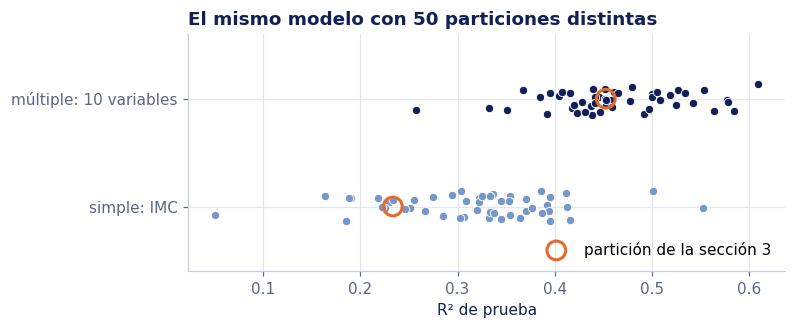

In [24]:
rng = np.random.default_rng(SEMILLA)
fig, ax = plt.subplots(figsize=(7, 2.8))

for fila, (valores, color) in enumerate([(r2_simple, AZUL), (r2_multiple, AZUL_OSCURO)]):
    ax.scatter(valores, fila + rng.uniform(-0.15, 0.15, len(valores)), s=30, color=color,
               edgecolor="white", linewidth=0.6)
    # la semilla 42 es la partición de la sección 3
    ax.scatter(valores[SEMILLA], fila, s=150, facecolor="none", edgecolor=NARANJA, linewidth=2,
               label="partición de la sección 3" if fila == 0 else None)

ax.set_yticks([0, 1], ["simple: IMC", "múltiple: 10 variables"])
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("R² de prueba")
ax.set_title("El mismo modelo con 50 particiones distintas")
ax.legend(loc="lower right")
plt.show()

**Lectura.** El R² de la múltiple va de 0.26 a 0.61 según el sorteo, y el de la simple, de 0.05 a 0.55. La partición de la sección 3 (anillo naranja) cayó justo en la mediana de la múltiple, pero pudo no ser así. Con 89 pacientes de prueba, un solo número de una sola partición es poco para comparar modelos. La sesión 12 formaliza la alternativa, la validación cruzada, que promedia sobre varias particiones.

---

## 4. Residuales

El residual de cada paciente es lo observado menos lo predicho, $e_i = y_i - \hat{y}_i$ (slide 33). Graficados contra el valor predicho, ayudan a revisar varios de los supuestos del slide 18. Si el modelo está bien planteado, se ven como una nube sin patrón alrededor de cero.

Usamos el modelo múltiple de la sección 2. Para tener con qué comparar, agregamos dos casos sintéticos, construidos para que cada patrón de alarma se vea: una relación curva ajustada con una recta, y una relación lineal cuyo ruido crece con *x*.

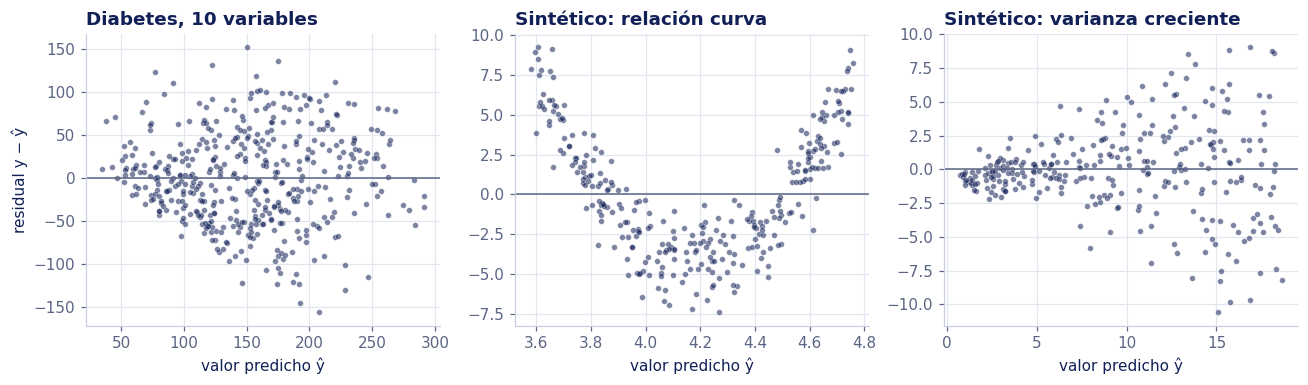

In [25]:
pred_todos = modelo_multiple.predict(X)
residuales = y - pred_todos

# Dos casos sintéticos, cada uno con un patrón de alarma
rng = np.random.default_rng(SEMILLA)
x_sint = rng.uniform(0, 10, 300)
y_curva = 0.5 * (x_sint - 5) ** 2 + rng.normal(0, 1.5, 300)        # relación curva
y_embudo = 2 * x_sint + rng.normal(0, 0.3 + 0.5 * x_sint)          # ruido que crece con x

casos = [("Diabetes, 10 variables", pred_todos, residuales)]
for titulo, y_sint in [("Sintético: relación curva", y_curva),
                       ("Sintético: varianza creciente", y_embudo)]:
    recta_sint = LinearRegression().fit(x_sint.reshape(-1, 1), y_sint)
    pred_sint = recta_sint.predict(x_sint.reshape(-1, 1))
    casos.append((titulo, pred_sint, y_sint - pred_sint))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, (titulo, pred, res) in zip(axes, casos):
    ax.axhline(0, color=GRIS, linewidth=1)
    ax.scatter(pred, res, s=14, color=AZUL_OSCURO, alpha=0.55, edgecolor="white", linewidth=0.3)
    ax.set_title(titulo)
    ax.set_xlabel("valor predicho ŷ")
axes[0].set_ylabel("residual y − ŷ")
fig.tight_layout()
plt.show()

**Lectura.** En la diabetes (izquierda) no hay un patrón claro: la nube se reparte alrededor de cero en todo el rango de predicciones, sin curva ni embudo evidentes. El borde diagonal abajo a la izquierda no es un problema del modelo: como la progresión mínima es 25, un residual nunca puede ser menor que 25 − ŷ.

En los casos sintéticos, en cambio, el patrón salta a la vista. La curva (centro) dice que la relación no es lineal: la recta se pasa en el centro y se queda corta en los extremos. El embudo (derecha) dice que el error crece con la predicción: la varianza no es constante. Ninguno de los dos se detecta mirando solo el R².

La cuarta señal del slide 33, un orden en el tiempo, no aplica aquí: los pacientes no tienen un orden.

---

## 5. Ajustar una línea: explicar una asociación

Hasta aquí usamos la regresión para **predecir**, y por eso la medimos con datos que el modelo no vio. El slide 35 menciona otro uso, el de los estudios clínicos de asociación: **explicar** cómo se relaciona una variable con un desenlace. La pregunta ya no es cuánto valdrá la progresión de un paciente nuevo, sino cuánto cambia, en promedio, por cada kg/m² de IMC.

En ese uso lo que importa es el coeficiente y su incertidumbre, no el error de predicción. Por eso se ajusta con todos los pacientes y cada coeficiente se reporta con su intervalo de confianza.

### De la correlación a la pendiente

La correlación de la sección 1 y la pendiente de la regresión simple miden la misma asociación en dos escalas. La correlación no tiene unidades y es simétrica; la pendiente está en unidades de *y* por unidad de *x*:

$$\theta_1 = r\,\frac{s_y}{s_x} \qquad\qquad R^2 = r^2$$

In [26]:
r = X["bmi"].corr(y)

print(f"r           = {r:.3f}")
print(f"r · sy / sx = {r * y.std() / X['bmi'].std():.3f}    θ1 de la sección 1: {theta1:.3f}")
print(f"r²          = {r ** 2:.3f}    R² de la regresión simple: {modelo_simple.score(X[['bmi']], y):.3f}")

r           = 0.586
r · sy / sx = 10.233    θ1 de la sección 1: 10.233
r²          = 0.344    R² de la regresión simple: 0.344


### Asociación cruda y ajustada

scikit-learn está pensado para predecir y no reporta intervalos de confianza. Para explicar se usa **statsmodels**, que produce la tabla que aparece en los artículos clínicos. Su interfaz de fórmulas se lee como el modelo: `"target ~ bmi"` es la progresión explicada por el IMC, y cada variable que se suma a la derecha es una variable por la que se ajusta.

In [27]:
import statsmodels.formula.api as smf

cruda = smf.ols("target ~ bmi", data=tabla).fit()
ajustada = smf.ols("target ~ bmi + age + sex + bp + s1 + s2 + s3 + s4 + s5 + s6", data=tabla).fit()

filas = {}
for nombre, modelo in [("cruda: solo IMC", cruda), ("ajustada: 10 variables", ajustada)]:
    inferior, superior = modelo.conf_int().loc["bmi"]
    filas[nombre] = {"θ bmi": f"{modelo.params['bmi']:.2f}",
                     "IC 95 %": f"{inferior:.2f} a {superior:.2f}",
                     "p": f"{modelo.pvalues['bmi']:.1e}",
                     "R²": f"{modelo.rsquared:.3f}"}
pd.DataFrame(filas).T

,θ bmi,IC 95 %,p,R²
cruda: solo IMC,10.23,8.91 a 11.56,3.5e-42,0.344
ajustada: 10 variables,5.60,4.19 a 7.01,4.3e-14,0.518


**Lectura.** Sin ajustar, cada kg/m² de IMC se asocia con 10.2 unidades más de progresión, con un intervalo de confianza de 8.9 a 11.6. Ajustando por las otras nueve variables, el efecto baja a 5.6, de 4.2 a 7.0: casi la mitad de la asociación cruda venía de lo que el IMC comparte con la presión, los triglicéridos y lo demás (sección 2). En un artículo se reportaría así: «por cada kg/m² de IMC, la progresión aumentó 5.6 unidades (IC 95 %: 4.2 a 7.0), ajustando por edad, sexo, presión arterial y mediciones séricas».

La tabla completa del modelo ajustado:

In [28]:
intervalos = ajustada.conf_int()
pd.DataFrame({
    "θ": ajustada.params,
    "IC 95 % inf.": intervalos[0],
    "IC 95 % sup.": intervalos[1],
    "p": ajustada.pvalues,
}).round(3)

,θ,IC 95 % inf.,IC 95 % sup.,p
Intercept,-334.567,-467.148,-201.986,0.000
bmi,5.603,4.194,7.012,0.000
age,-0.036,-0.463,0.390,0.867
sex,-22.860,-34.330,-11.389,0.000
bp,1.117,0.674,1.560,0.000
s1,-1.090,-2.217,0.037,0.058
s2,0.746,-0.297,1.790,0.160
s3,0.372,-1.166,1.910,0.635
s4,6.534,-5.178,18.245,0.273
s5,68.483,37.685,99.282,0.000


**Lectura.** Los coeficientes son los mismos que dio scikit-learn en la sección 2; lo nuevo es la incertidumbre. Los intervalos del IMC, la presión, el sexo y `s5` no incluyen el cero. Los de `s1` y `s2` sí, y son anchos: con las dos en el modelo, los datos no alcanzan a separar sus efectos. Es la colinealidad de la sección 2 vista desde la incertidumbre. No dice que el colesterol no importe; dice que este modelo no puede atribuir su efecto a una de las dos.

Dos advertencias. Estos intervalos dependen de los supuestos de independencia, homocedasticidad y normalidad del slide 18: para predecir no hacen falta, para explicar sí, y por eso se revisan los residuales. Y una asociación ajustada sigue sin ser causal: solo descuenta las variables que se midieron.

### ¿Cómo se detecta la colinealidad?

Sin quitar variables una por una, se mide con el **factor de inflación de la varianza** (VIF). Para cada variable se ajusta una regresión de esa variable contra todas las demás, y con el $R_j^2$ de ese ajuste

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

dice cuánto se infla la varianza de su coeficiente por lo que comparte con las otras. Un VIF de 1 indica que no comparte nada; por encima de 10 suele considerarse un problema.

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# A es la matriz con la columna de unos de la sección 2; la columna 0 es el intercepto
vif = pd.Series([variance_inflation_factor(A, j) for j in range(1, A.shape[1])],
                index=X.columns, name="VIF")
vif.sort_values(ascending=False).round(1).to_frame()

,VIF
s1,59.2
s2,39.2
s3,15.4
s5,10.1
s4,8.9
bmi,1.5
s6,1.5
bp,1.5
sex,1.3
age,1.2


**Lectura.** `s1` (59) y `s2` (39) están muy por encima del umbral, seguidas de `s3` (15) y `s5` (10). Las cuatro son mediciones de lípidos y comparten información: el LDL es parte del colesterol total, y `s4` es el cociente de `s1` entre `s3`. El IMC, la edad, el sexo, la presión y la glucosa quedan entre 1.2 y 1.5. Por eso el coeficiente del IMC es estable y los de `s1` y `s2` no.

---

## 6. ¿Y si la variable objetivo es una clase?

Hasta aquí la pregunta fue **¿cuánto?**: cuánto avanzará la enfermedad. Muchas veces la pregunta es **¿cuál?**: si la progresión será alta o no (slide 36). Para verlo convertimos la progresión en una clase. El corte en 200 es nuestro, no clínico.

In [30]:
alta = (y >= 200).astype(int)          # 1: progresión alta; 0: no
print(f"Progresión alta: {alta.sum()} de {len(alta)} pacientes ({alta.mean():.0%})")

Progresión alta: 127 de 442 pacientes (29%)


Con la clase codificada como 0 y 1, nada impide ajustar la misma regresión lineal: la recta predice un número, y si llega a 0.5 decimos que la clase es 1. Lo hacemos solo con el IMC, para poder graficarlo, y con la misma partición de la sección 3.

In [31]:
X_entrena_c, X_prueba_c, alta_entrena, alta_prueba = train_test_split(
    X[["bmi"]], alta, test_size=0.2, random_state=SEMILLA)

recta = LinearRegression().fit(X_entrena_c, alta_entrena)
y_gorro = recta.predict(X_prueba_c)        # números, no clases
clase = (y_gorro >= 0.5).astype(int)       # umbral: ŷ ≥ 0.5 → progresión alta

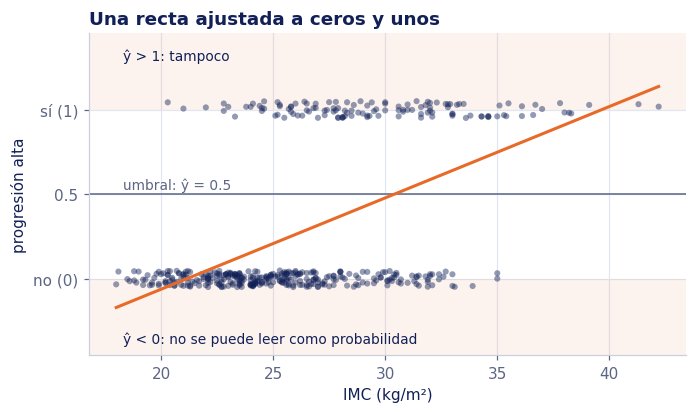

In [32]:
rng = np.random.default_rng(SEMILLA)
fig, ax = plt.subplots(figsize=(7, 3.8))

ax.axhspan(-0.45, 0, color=NARANJA, alpha=0.08, linewidth=0)
ax.axhspan(1, 1.45, color=NARANJA, alpha=0.08, linewidth=0)
ax.axhline(0.5, color=GRIS, linewidth=1)
ax.scatter(X["bmi"], alta + rng.uniform(-0.05, 0.05, len(alta)), s=16,
           color=AZUL_OSCURO, alpha=0.45, edgecolor="none")
malla = np.linspace(X["bmi"].min(), X["bmi"].max(), 100)
ax.plot(malla, recta.intercept_ + recta.coef_[0] * malla, color=NARANJA, linewidth=2)

ax.text(18.3, 0.53, "umbral: ŷ = 0.5", color=GRIS, fontsize=9)
ax.text(18.3, -0.38, "ŷ < 0: no se puede leer como probabilidad", color=AZUL_OSCURO, fontsize=9)
ax.text(18.3, 1.36, "ŷ > 1: tampoco", color=AZUL_OSCURO, fontsize=9, va="top")
ax.set_yticks([0, 0.5, 1], ["no (0)", "0.5", "sí (1)"])
ax.set_ylim(-0.45, 1.45)
ax.set_xlabel("IMC (kg/m²)")
ax.set_ylabel("progresión alta")
ax.set_title("Una recta ajustada a ceros y unos")
plt.show()

**Lectura.** La recta cruza el umbral cerca de un IMC de 30: por arriba predice «progresión alta», por abajo «no». Pero no se queda entre 0 y 1. Para un IMC menor que 21 predice valores negativos, y cerca de 40 empieza a pasar de 1. Ninguno de esos valores se puede leer como probabilidad.

¿Qué tan bien clasifica? Cuatro números sobre los pacientes de prueba.

In [33]:
from sklearn.metrics import accuracy_score

siempre_no = np.zeros(len(alta_prueba), dtype=int)
fuera = ((y_gorro < 0) | (y_gorro > 1)).sum()
detectados = ((clase == 1) & (alta_prueba == 1)).sum()

print(f"Aciertos de la recta:            {accuracy_score(alta_prueba, clase):.1%}")
print(f"Aciertos diciendo siempre «no»:  {accuracy_score(alta_prueba, siempre_no):.1%}")
print(f"ŷ fuera de [0, 1]:               {fuera} de {len(y_gorro)}")
print(f"Progresiones altas detectadas:   {detectados} de {alta_prueba.sum()}")

Aciertos de la recta:            74.2%
Aciertos diciendo siempre «no»:  73.0%
ŷ fuera de [0, 1]:               16 de 89
Progresiones altas detectadas:   8 de 24


**Lectura.** Un 74 % de aciertos suena bien hasta compararlo con la línea base de clasificación: decir siempre «no» acierta 73 %, porque la mayoría de los pacientes no tiene progresión alta. La recta detecta 8 de los 24 pacientes de prueba que sí la tienen, y 16 de sus 89 predicciones caen fuera de [0, 1].

El problema no es de programación: la regresión lineal está resolviendo otro problema. Minimiza la distancia cuadrática a los ceros y unos en lugar de modelar la probabilidad de cada clase. En la próxima sesión, la regresión logística cambia la recta por una curva que se queda entre 0 y 1, y la matriz de confusión desglosa aciertos y errores por clase, que es justo lo que el porcentaje de aciertos esconde.

---

### Para la Tarea 3

La tarea repite las secciones 3 y 6 con otro conjunto: la calidad de 1599 vinos tintos portugueses (Cortez *et al.*, 2009). Su variable objetivo, `quality`, es una calificación de 3 a 8 que se puede tratar como número o convertir en clase. El archivo está en `datos/` y se carga como en las sesiones anteriores:

- **En tu máquina.** La primera línea funciona tal cual desde la carpeta del repositorio clonado.
- **En Colab.** Comenta la primera línea y descomenta la segunda.

In [ ]:
vinos = pd.read_csv("datos/winequality-red.csv")
# vinos = pd.read_csv("https://raw.githubusercontent.com/husseinlopez/icd2026/main/datos/winequality-red.csv")

print(f"{vinos.shape[0]} vinos × {vinos.shape[1]} columnas")
vinos["quality"].value_counts().sort_index()

1599 vinos × 12 columnas


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Las instrucciones y la fecha de entrega están en la plataforma del curso.

---

### Declaración de uso de IA generativa

Este notebook fue elaborado con apoyo de Claude (Anthropic) para estructurar el contenido a partir de las diapositivas de la sesión, redactar el texto explicativo y seleccionar los conjuntos de datos de ejemplo. El diseño pedagógico, la selección de temas y la revisión final son responsabilidad del titular del curso.

### Referencias

- VanderPlas, J. (2022). *Python Data Science Handbook*, 2a ed. O'Reilly. [Capítulo 42: In Depth: Linear Regression](https://jakevdp.github.io/PythonDataScienceHandbook/05.06-linear-regression.html)
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2a ed., capítulo 3. Springer. https://www.statlearning.com/
- Efron, B., Hastie, T., Johnstone, I., & Tibshirani, R. (2004). Least angle regression. *The Annals of Statistics*, 32(2), 407-499.
- Shmueli, G. (2010). To explain or to predict? *Statistical Science*, 25(3), 289-310.
- Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, 47(4), 547-553.
- [scikit-learn: LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) · [load_diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html) · [Métricas de regresión](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)
- [statsmodels: modelos de regresión lineal](https://www.statsmodels.org/stable/regression.html)